# Demo 1 CLIP model

In this notebook, we explore how CLIP (Contrastive Language–Image Pretraining) represents images and text in a *shared embedding space*. **Note that this notebook is purely for demonstration purpose, you do not need to learn the code inside this notebook.**

### Hypothesis

If CLIP successfully aligns vision and language, then semantically related images and text descriptions will have **similar embeddings** (i.e., are close in vector space).

For example:
* An image of a dog and the text *"a dog"* should be close
* An image of a car and the text *"a car"* should also be close
* Unrelated pairs (e.g., dog image and *"a building"*) should be farther apart

### Approach

We will:

1. Encode images and their corresponding text descriptions into vectors independently
2. Compare them in a shared space
3. Project embeddings into 2D for visualization

### Goal

By the end, we should clearly observe that:

* Matching image–text pairs cluster together
* Unrelated vectors are far from each other


## 1.1. Install Libraries and Download CLIP model

In [1]:
# Install the necessary libraries
!pip install -q torch torchvision transformers matplotlib numpy Pillow umap-learn
print("Libraries installed successfully!")
# Import libraries and load the CLIP model from Hugging Face

from transformers import CLIPProcessor, CLIPModel

print("Downloading and loading the CLIP model... (this might take a minute)")
model_id = "openai/clip-vit-large-patch14"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)
print("Model loaded!")

Libraries installed successfully!


c:\Users\Akshay T P\anaconda3\envs\rag-chatbot\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights: 100%|██████████| 590/590 [00:00<00:00, 5999.36it/s]


Model loaded!


## 1.2. Load images

Displaying: Photos/AstonMartinValhalla.jpg
Displaying: Photos/Spitfire_Plane.jpg
Displaying: Photos/Challenger2_MBT.jpg
Displaying: Photos/British_Shorthair_Cat.jpg
Displaying: Photos/Golden_Retriever_Dog.jpg
Displaying: Photos/PanchiKun_Monkey.jpeg


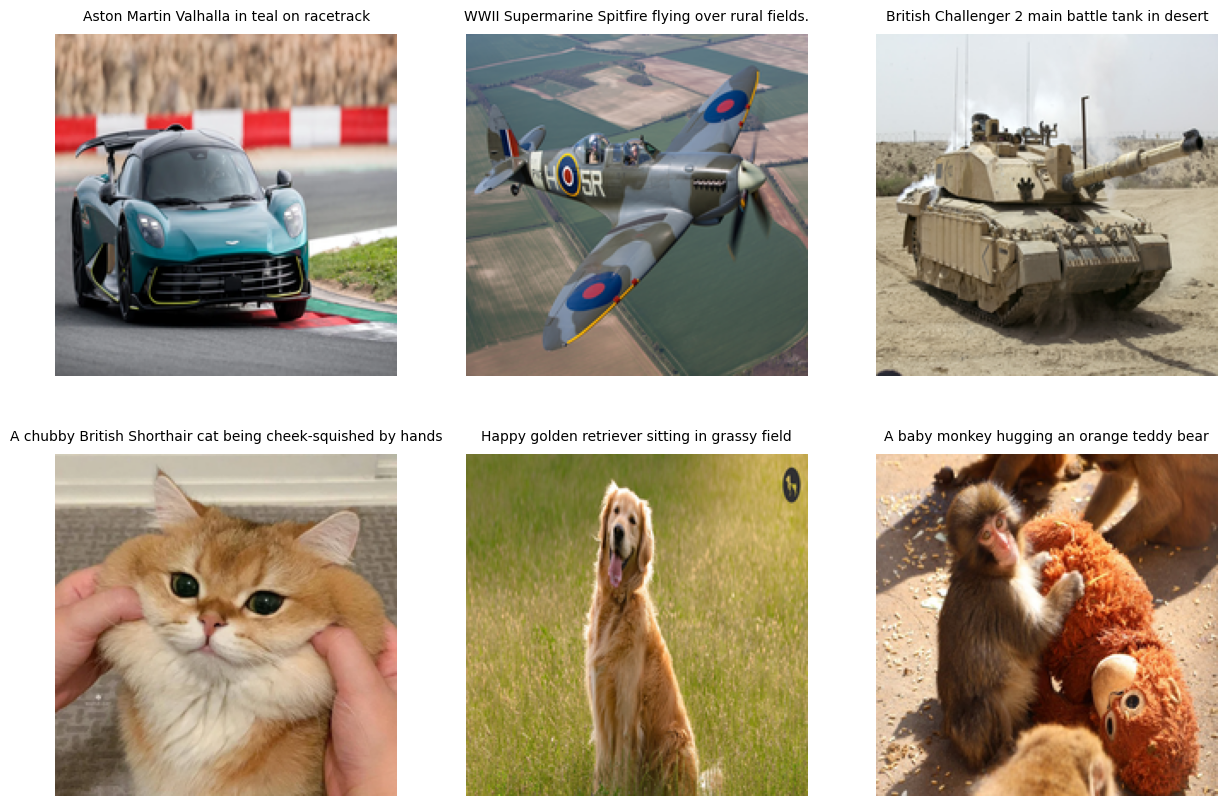

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. Configuration: Set the uniform size for all images
# Dimensions are represented as [width, height]
target_size = (200, 200)

# 2. Data: List of local file paths for the images
image_paths = [
    "Photos/AstonMartinValhalla.jpg",
    "Photos/Spitfire_Plane.jpg",
    "Photos/Challenger2_MBT.jpg",
    "Photos/British_Shorthair_Cat.jpg",
    "Photos/Golden_Retriever_Dog.jpg",
    "Photos/PanchiKun_Monkey.jpeg"
]

# 3. Processing Loop
processed_images = []

for path in image_paths:
    try:
        # Open the image file
        with Image.open(path) as img:
            # Resize image using Lanczos sampling for high-quality downsampling
            img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
            processed_images.append(img_resized)
            
            # 4. Display the image
            print(f"Displaying: {path}")
            #img_resized.show() # This opens the image in your default viewer
            
    except FileNotFoundError:
        print(f"Error: The file at {path} was not found.")

# 4. Define the text descriptions for each image
texts = [
    "Aston Martin Valhalla in teal on racetrack",
    "WWII Supermarine Spitfire flying over rural fields.",
    "British Challenger 2 main battle tank in desert",
    "A chubby British Shorthair cat being cheek-squished by hands",
    "Happy golden retriever sitting in grassy field",
    "A baby monkey hugging an orange teddy bear"
]

# 5. Display all images in a grid using Matplotlib
plt.figure(figsize=(15, 10))
for i, img in enumerate(processed_images):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(texts[i], fontsize=10, pad=10, wrap=True)  # Display text description as title
    plt.axis('off') # Hide X and Y axes for a cleaner look
plt.show()

## 1.3. Get All Vectors (Image and Text)

In [3]:
"""
Image and Text Feature Extraction using CLIP
============================================

This script takes images and text descriptions, and extracts their features 
using a CLIP model. Features are then converted to numpy arrays for easy use.
"""

import torch


# ------------------------------------------------------------------------------
# Prepare Inputs for the Model
# ------------------------------------------------------------------------------

# Convert images and texts into the format the model expects
image_inputs = processor(
    images=processed_images, 
    return_tensors="pt", 
    padding=True
)

text_inputs = processor(
    text=texts, 
    return_tensors="pt", 
    padding=True
)

# ------------------------------------------------------------------------------
# Extract Features using CLIP Model
# ------------------------------------------------------------------------------

# Disable gradient calculation (we are only doing inference, not training)
with torch.no_grad():
    # Get feature vectors for images
    image_features = model.get_image_features(**image_inputs)
    
    # Get feature vectors for texts
    text_features = model.get_text_features(**text_inputs)

# ------------------------------------------------------------------------------
# Convert Features to NumPy Arrays
# ------------------------------------------------------------------------------

# Move features from GPU to CPU and convert to numpy
np_image_features = image_features.pooler_output.detach().cpu().numpy()
np_text_features = text_features.pooler_output.detach().cpu().numpy()

# ------------------------------------------------------------------------------
# Display Results
# ------------------------------------------------------------------------------

print("Image Features Shape:", np_image_features.shape)
print("Text Features Shape: ", np_text_features.shape)
print("\n" + "="*60)

print("Image Features:")
print(np_image_features)
print("\n" + "-"*60)

print("Text Features:")
print(np_text_features)
# Convert images and texts into the format the model expects

Image Features Shape: (6, 768)
Text Features Shape:  (6, 768)

Image Features:
[[ 0.72388583 -0.2283375   0.5417453  ...  0.29458866 -0.0176726
   0.11671332]
 [-0.11820315 -0.4772129   1.0776992  ...  0.9177665  -0.39518058
  -0.6229485 ]
 [ 0.16522947 -0.8185445  -0.26846606 ...  0.3044409  -0.27814484
  -0.68104684]
 [ 0.70928985  0.35084915  0.7957529  ... -0.04771163  0.6617955
  -0.66374326]
 [ 0.09487102  1.0718963  -0.3574214  ...  0.21062467  0.56346977
  -0.16131921]
 [-0.69512856  0.76820207 -0.3764555  ... -0.00135587 -0.33351344
   0.9303776 ]]

------------------------------------------------------------
Text Features:
[[ 0.05292665 -0.29819426  0.37234747 ... -0.36355913  0.05104033
   0.24412514]
 [ 0.45928845 -0.6845447   0.36909908 ...  0.30941445 -0.37139183
  -0.2835225 ]
 [-0.5811351  -0.48274565 -0.5113643  ... -0.29593444  0.28018954
  -0.32439566]
 [-0.42381716  0.40817058 -0.12161691 ... -0.56719345 -0.17795518
  -0.51931643]
 [-0.10817965  0.8117816  -0.092759

## 1.4. UMAP (Uniform Manifold Approximation and Projection)
UMAP (Uniform Manifold Approximation and Projection) is a nonlinear manifold-learning technique that does a much better job. It works in two main steps:

It builds a fuzzy topological graph of the high-dimensional data by connecting each point to its nearest neighbors with a smooth distance kernel (so close points have strong connections, far points have weak or none).
It then optimizes a low-dimensional layout (usually 2D) that minimizes the cross-entropy between the high-dimensional graph and the new 2D graph, preserving both local neighborhoods and the overall global structure.
This produces cleaner, more separated clusters and more interpretable visualizations of CLIP embeddings than PCA ever could.

🔹 Step 1: Normalizing features to unit vectors (required for CLIP)...
🔹 Step 2: Centering both modalities to remove the modality gap...
   → 6 image embeddings + 6 text embeddings = 12 total points
🔹 Step 3: Running UMAP to project everything into 2D...


c:\Users\Akshay T P\anaconda3\envs\rag-chatbot\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   ✅ UMAP finished! Ready to visualize.
🔹 Step 4: Creating the plot...


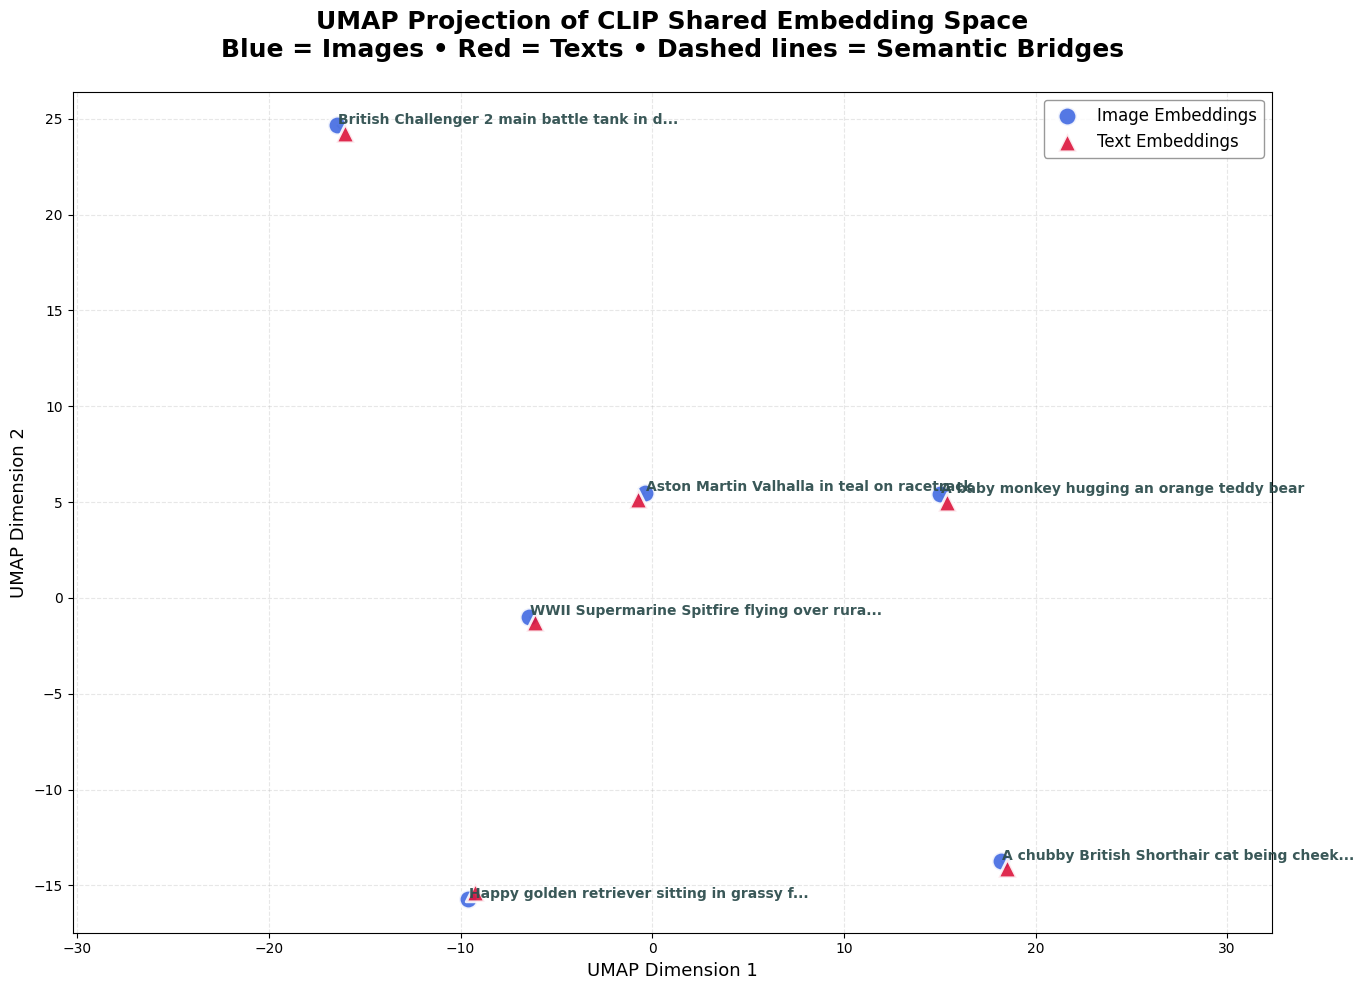

🎉 Visualization complete!


: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap

# ================================================================
# 1. PREPARE AND NORMALIZE DATA
# ================================================================
print("🔹 Step 1: Normalizing features to unit vectors (required for CLIP)...")

# CLIP uses cosine similarity → we must make every vector length = 1
img_norm = np_image_features / np.linalg.norm(np_image_features, axis=1, keepdims=True)
text_norm = np_text_features / np.linalg.norm(np_text_features, axis=1, keepdims=True)

# ================================================================
# 2. CLOSE THE "MODALITY GAP" (very important trick!)
# ================================================================
print("🔹 Step 2: Centering both modalities to remove the modality gap...")

# Image embeddings and text embeddings often live in slightly different parts of the space.
# Subtracting the mean of each group moves both clouds to the same center.
# This makes the visualization much cleaner and more accurate.
img_centered = img_norm - img_norm.mean(axis=0)
text_centered = text_norm - text_norm.mean(axis=0)

# Combine everything for UMAP (images on top, texts on bottom)
all_features = np.vstack((img_centered, text_centered))
n_samples = len(np_image_features)   # how many image-text pairs we have

print(f"   → {n_samples} image embeddings + {n_samples} text embeddings = {all_features.shape[0]} total points")

# ================================================================
# 3. APPLY UMAP (2D projection)
# ================================================================
print("🔹 Step 3: Running UMAP to project everything into 2D...")

# Easy-to-understand parameter explanations:
reducer = umap.UMAP(
    n_neighbors=2,      # Small number = focus on local clusters (good for CLIP)
    min_dist=0.2,       # How spread out points can be (0.3 gives nice separation)
    metric='cosine',    # The correct distance for CLIP embeddings
    random_state=42,    # Makes results exactly the same every time you run it
)

features_2d = reducer.fit_transform(all_features)

# Split the 2D points back into images and texts
img_2d = features_2d[:n_samples]
text_2d = features_2d[n_samples:]

print("   ✅ UMAP finished! Ready to visualize.")

# ================================================================
# 4. CREATE THE BEAUTIFUL VISUALIZATION
# ================================================================
print("🔹 Step 4: Creating the plot...")

plt.figure(figsize=(14, 10))  # nice big canvas

# Plot IMAGE points (blue circles)
plt.scatter(img_2d[:, 0], img_2d[:, 1],
            c='royalblue', marker='o', s=180,
            label='Image Embeddings',
            edgecolors='white', linewidth=2, alpha=0.9, zorder=3)

# Plot TEXT points (red triangles)
plt.scatter(text_2d[:, 0], text_2d[:, 1],
            c='crimson', marker='^', s=180,
            label='Text Embeddings',
            edgecolors='white', linewidth=2, alpha=0.9, zorder=3)

# Draw connecting lines + labels for every pair
for i in range(n_samples):
    # Semantic bridge line (shows how well image and text are aligned)
    plt.plot([img_2d[i, 0], text_2d[i, 0]],
             [img_2d[i, 1], text_2d[i, 1]],
             color='gray', linestyle='--', alpha=0.35, linewidth=1.2, zorder=1)
    
    # Label (truncated so it doesn't get too long and messy)
    caption = texts[i]
    if len(caption) > 45:
        caption = caption[:42] + "..."
    plt.text(img_2d[i, 0] + 0.06, img_2d[i, 1] + 0.06,
             caption,
             fontsize=10, fontweight='bold', color='darkslategray',
             alpha=0.95, zorder=4)

# Final plot styling
plt.title("UMAP Projection of CLIP Shared Embedding Space\n"
          "Blue = Images • Red = Texts • Dashed lines = Semantic Bridges",
          fontsize=18, pad=25, fontweight='bold')

plt.xlabel("UMAP Dimension 1", fontsize=13)
plt.ylabel("UMAP Dimension 2", fontsize=13)

plt.legend(frameon=True, facecolor='white', edgecolor='gray', fontsize=12, loc='best')
plt.grid(True, linestyle='--', alpha=0.3)

# Keep the shape natural (important for cosine space)
plt.gca().set_aspect('equal', adjustable='datalim')

plt.tight_layout()

# Optional: save a high-quality version
# plt.savefig("clip_umap_visualization.png", dpi=300, bbox_inches='tight')

plt.show()

print("🎉 Visualization complete!")